In [ ]:
!pip install google-play-scraper

# mengimpor pustaka google play_play_scraper untuk mengakses ulasan dan informasi aplikasi dari google play store
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd # panda untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None # menonaktifkan peringatan chaining
import numpy as np # numpy untuk komputasi numerik
seed = 0
np.random.seed(seed) # mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt # matplotlib untuk visualisasi data
import seaborn as sns # seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt # manipulasi data waktu dan tanggal
import re # modul untuk bekerja dengan ekspresi reguler
import string # berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize # tokenisasi teks
from nltk.corpus import stopwords # daftar kata kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Stemming (penghilang imbuhan kata) dalam bahasa indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory # menghapus kata kata berhenti dalam bahasa indonesia

from wordcloud import WordCloud # membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk # import pustaka nltk (natural language toolkit)
nltk.download('punkt') # mengunduh dataset yang diperlukan untuk tokenisasi teks
nltk.download('stopwords') # mengunduh dataset yang berisi daftar kata kata berhenti (stopwords dalam berbagai bahasa)
nltk.download('punkt_tab')




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari google play store
from google_play_scraper import app, reviews_all, Sort

# mengambil semua ulasan dari aplikasi dengan id 'ovo.id' di google play store
# proses scraping mungkin memerlukan beberapa saat tergantung pada jumlah ulasan yang ada
scrapreview = reviews_all(
    'ovo.id',                 # id aplikasi
    lang='id',                # bahasa ulasan (default: 'en')
    country='id',             # negara (default: 'us')
    sort=Sort.MOST_RELEVANT,  # urutan ulasan (default: Sort.MOST_RELEVANT)
    count=1000                # jumlah maksimum ulasan yang ingin diambil
)


In [ ]:
# menyimpan ulasan dalam file csv
import csv

with open ('ulasan_aplikasi.csv', mode='w', newline='', encoding='utf-8') as file:
  writer = csv.writer(file)
  writer.writerow(['Review']) # menulis header kolom
  for review in scrapreview:
    writer.writerow([review['content']]) # menulis konten ulasan ke dalam file csv

In [ ]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('ulasan_aplikasi.csv', index=False)

# membuat dataframe dari hasil scrapview
app_reviews_df = pd.DataFrame(scrapreview)

# menghitung jumlah baris dan kolom dalam dataframe
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [ ]:
# menampilkan lima baris pertama dalam dataframe app_reviews_df

app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,39386497-5dd1-498f-88e9-a756d4744aee,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"fitur ubah nomor gak guna, karena nomor lama h...",1,540,3.150.0,2026-01-10 14:38:15,None,NaT,3.150.0
1,c9ccdd5c-7ce9-4512-a789-5c917bfa8983,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya aplikasi ini bagus, tapi karena bia...",3,7,3.153.0,2026-02-07 01:55:26,None,NaT,3.153.0
2,b24a0639-4977-4124-a887-9f9ddd8978fd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Hati-hati jangan simpen uang banyak di apk ini...,1,1420,3.149.0,2025-12-16 07:28:52,None,NaT,3.149.0
3,3585109d-6b29-4713-a1ca-86dd095e2439,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mau isi pulsa atau pembayaran yg lain ngak bis...,1,12,3.153.0,2026-02-03 10:41:24,None,NaT,3.153.0
4,e9929b0b-162c-4fc6-b6a9-ea43db49bd07,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sering kendala saat log in. Muncul keterangan:...,1,23,3.153.0,2026-02-01 03:49:44,None,NaT,3.153.0


In [ ]:
# menampilkan informasi tentang dataframe app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              135000 non-null  object        
 1   userName              135000 non-null  object        
 2   userImage             135000 non-null  object        
 3   content               134999 non-null  object        
 4   score                 135000 non-null  int64         
 5   thumbsUpCount         135000 non-null  int64         
 6   reviewCreatedVersion  105270 non-null  object        
 7   at                    135000 non-null  datetime64[ns]
 8   replyContent          88433 non-null   object        
 9   repliedAt             88433 non-null   datetime64[ns]
 10  appVersion            105270 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 11.3+ MB


In [ ]:
# membuat dataframe baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [ ]:
# menghapus baris duplikat dari dataframe clean_df
clean_df = clean_df.drop_duplicates()

# menghapus jumlah baris dan kolom dalam dataframe clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

# menampilkan informasi tentang dataframe clean_df setelah membersihkan nilai yang hilang (Nan)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68620 entries, 5 to 134998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              68620 non-null  object        
 1   userName              68620 non-null  object        
 2   userImage             68620 non-null  object        
 3   content               68620 non-null  object        
 4   score                 68620 non-null  int64         
 5   thumbsUpCount         68620 non-null  int64         
 6   reviewCreatedVersion  68620 non-null  object        
 7   at                    68620 non-null  datetime64[ns]
 8   replyContent          68620 non-null  object        
 9   repliedAt             68620 non-null  datetime64[ns]
 10  appVersion            68620 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 6.3+ MB


In [ ]:
def cleaningText(text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
  text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
  text = re.sub(r'RT[\s]', '', text) # menghapus RT
  text = re.sub(r"http\S+", '', text) # menghapus link
  text = re.sub(r'[0-9]+', '', text) # menghapus angka
  text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

  text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
  text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
  text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
  return text

def casefoldingText(text): # mengubah semua karakter dalam teks menjadi huruf kecil
  text = text.lower()
  return text

def tokenizingText(text): # memecah atau membagi string, teks menjadi daftar token
  text = word_tokenize(text)
  return text

def filteringText(text): # menghapus stopwords dalam teks
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)
  listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
  filtered = []
  for txt in text:
    if txt not in listStopwords:
      filtered.append(txt)
  text = filtered
  return text

def stemmingText(text): # mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
  # membuat objek stemmer
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()

  # memecah teks menjadi daftar kata
  words = text.split()

  # menerapkan stemming pada setiap kata dalam daftar
  stemmed_words = [stemmer.stem(word) for word in words]

  # menggabungkan kata-kata yang telah distem
  stemmed_text = ' '.join(stemmed_words)

  return stemmed_text

def toSentence(list_words): # mengubah daftar kata menjadi kalimat
  sentence = ' '.join(word for word in list_words)
  return sentence


In [ ]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "mks": "maksimal"}
def fix_slangwords(text):
  words = text.split()
  fixed_words = []

  for word in words:
    if word.lower() in slangwords:
      fixed_words.append(slangwords[word.lower()])
    else:
      fixed_words.append(word)

  fixed_text = ' '.join(fixed_words)
  return fixed_text


In [ ]:
# membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# mengubah huruf dalam text menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# mengganti kata kata slang dengan kata kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# memecah teks menjadi token (kata kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# menghapus kata kata stop (kata kata umum) dan menyimpannya di 'text_stopwords'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# menggabungkan token token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)


In [ ]:
import csv
import requests
from io import StringIO

# membaca data kamus kata kata positif dari github
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# mengirim permintaan HTTP untuk mendapatkan file CSV dari github

if response.status_code == 200:
  # jika permintaan berhasil
  reader = csv.reader(StringIO(response.text), delimiter=',')
  # membaca teks respons sebagai file csv menggunakan pembaca csv dengan pemisah koma

  for row in reader:
    # mengulangi setiap baris dalam file csv
    lexicon_positive[row[0]] = int(row[1])
    # menambahkan kata kata positif dan skornya ke dalam kamus lexicon_positive

else:
  print("Failed to fetch positive lexicon data")

# membaca data kamus kata kata negatif dari github
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# mengirim permintaan HTTP untuk mendapatkan file csv dari github

if response.status_code == 200:
  # jika permintaan berhasil
  reader = csv.reader(StringIO(response.text), delimiter=',')
  # membaca teks respons sebagai file csv menggunakan pembaca csv dengan pemisah koma

  for row in reader:
    # mengulangi setiap baris dalam file csv
    lexicon_negative[row[0]] = int(row[1])
    # menambahkan kata kata negatif dan skornya dalam kamus lexicon_negative

else:
  print("Failed to fetch negative lexicon data")







In [ ]:
# fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
  # for word in text:

  score = 0
  # inisialisasi skor sentimen ke 0

  for word in text:
    # mengulangi setiap kata dalam teks

    if (word in lexicon_positive):
      score = score + lexicon_positive[word]
      # jika ada kata dalam kamus positive, tambahkan skornya ke skor sentimen

  for word in text:
    # mengulangi setiap kata dalam teks (sekali lagi)

    if (word in lexicon_negative):
      score = score + lexicon_negative[word]
      # jika kata ada dalam kamus negative, kurangkan skornya dari skor sentimen

  polarity = ''
  # inisialisasi variabel polaritas

  if (score >= 0):
    polarity = 'positive'
    # jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positive
  elif (score < 0):
    polarity = 'negative'
    # jika skor sentimen kurang dari 0, maka polaritas adalah negative

  # else:
  # polarity = 'neutral'
  # ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika ingin diperlukan

  return score, polarity
  # mengembalikan skor sentimen dan polaritas teks


In [ ]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    40454
positive    28166
Name: count, dtype: int64


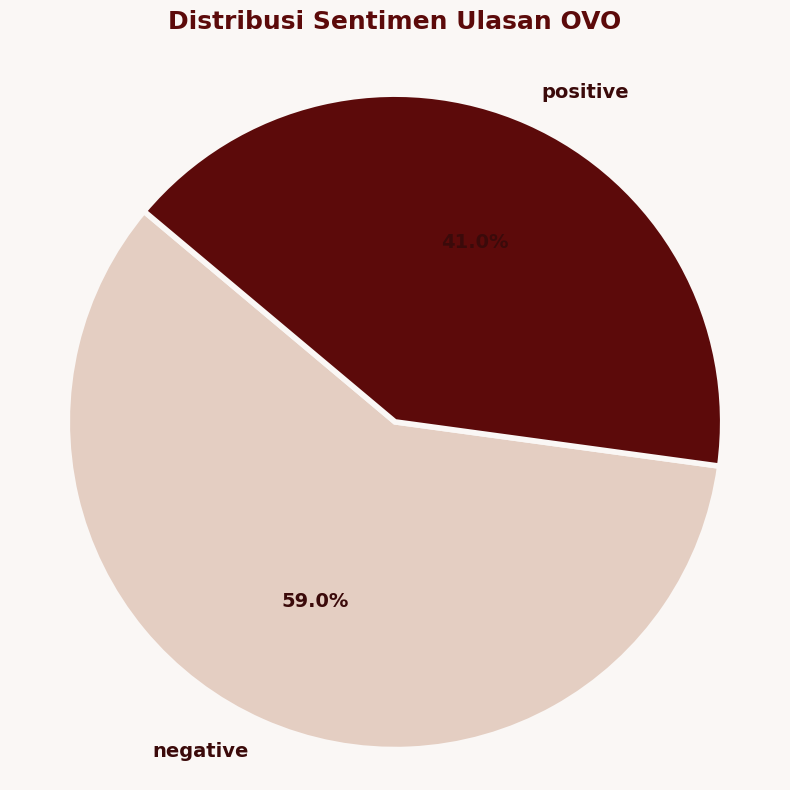

In [ ]:
import matplotlib.pyplot as plt

wine_maroon = "#5C0A0A"
soft_nude = "#E4CEC2"

sentiment_counts = clean_df['polarity'].value_counts()

color_map = {
    'positive': wine_maroon,
    'negative': soft_nude
}

colors = [color_map[label] for label in sentiment_counts.index]

plt.figure(figsize=(8,8), facecolor='#FAF7F5')

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={
        'edgecolor': '#FAF7F5',
        'linewidth': 4
    },
    textprops={
        'fontsize':14,
        'fontweight':'bold',
        'color':'#3B0A0A'
    }
)

plt.title(
    "Distribusi Sentimen Ulasan OVO",
    fontsize=18,
    fontweight='bold',
    color=wine_maroon,
    pad=25
)

plt.axis('equal')
plt.tight_layout()
plt.show()


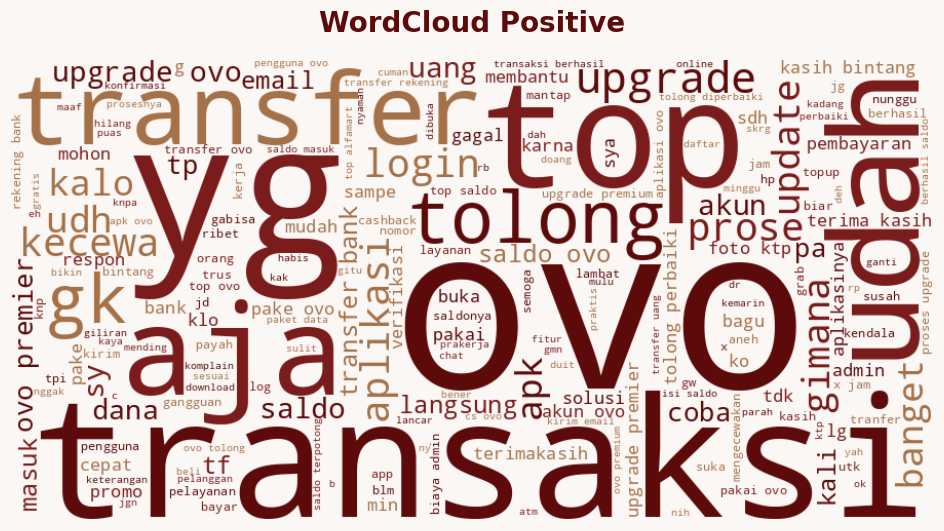

In [ ]:
import random
positive_palette = ["#5C0A0A", "#7A1C1C", "#A47148"]

def positive_color_func(*args, **kwargs):
    return random.choice(positive_palette)

positive_text = ' '.join(clean_df[clean_df['polarity']=='positive']['text_akhir'])

wc_positive = WordCloud(
    width=900,
    height=450,
    background_color="#FAF7F5",
    color_func=positive_color_func
).generate(positive_text)

plt.figure(figsize=(12,6), facecolor="#FAF7F5")
plt.imshow(wc_positive, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Positive", fontsize=20, fontweight="bold", color="#5C0A0A", pad=20)
plt.show()


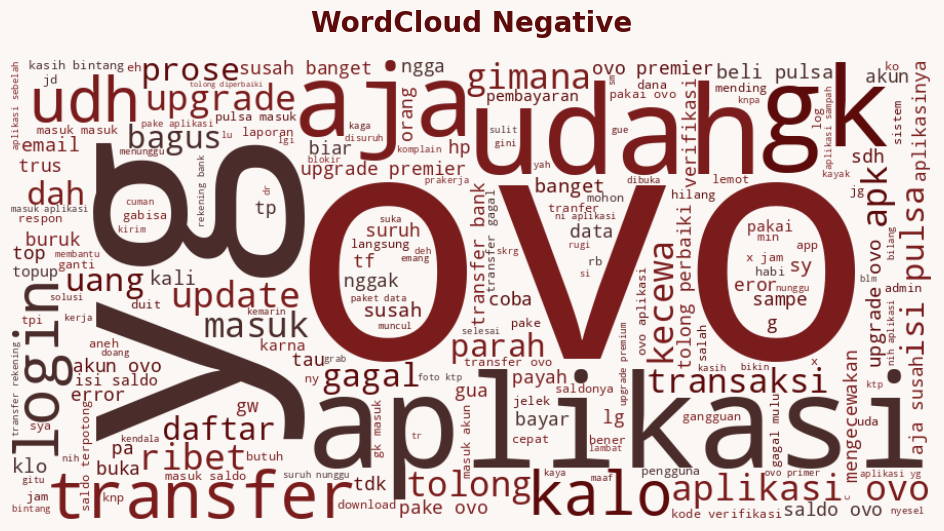

In [ ]:
import random

negative_palette = ["#5C0A0A", "#7A1C1C", "#4A2C2A"]

def negative_color_func(*args, **kwargs):
    return random.choices(
        negative_palette,
        weights=[0.45, 0.40, 0.15]  # burgundy lebih dominan
    )[0]

negative_text = ' '.join(clean_df[clean_df['polarity']=='negative']['text_akhir'])

wc_negative = WordCloud(
    width=900,
    height=450,
    background_color="#FAF7F5",
    color_func=negative_color_func
).generate(negative_text)

plt.figure(figsize=(12,6), facecolor="#FAF7F5")
plt.imshow(wc_negative, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Negative", fontsize=20, fontweight="bold", color="#5C0A0A", pad=20)
plt.show()


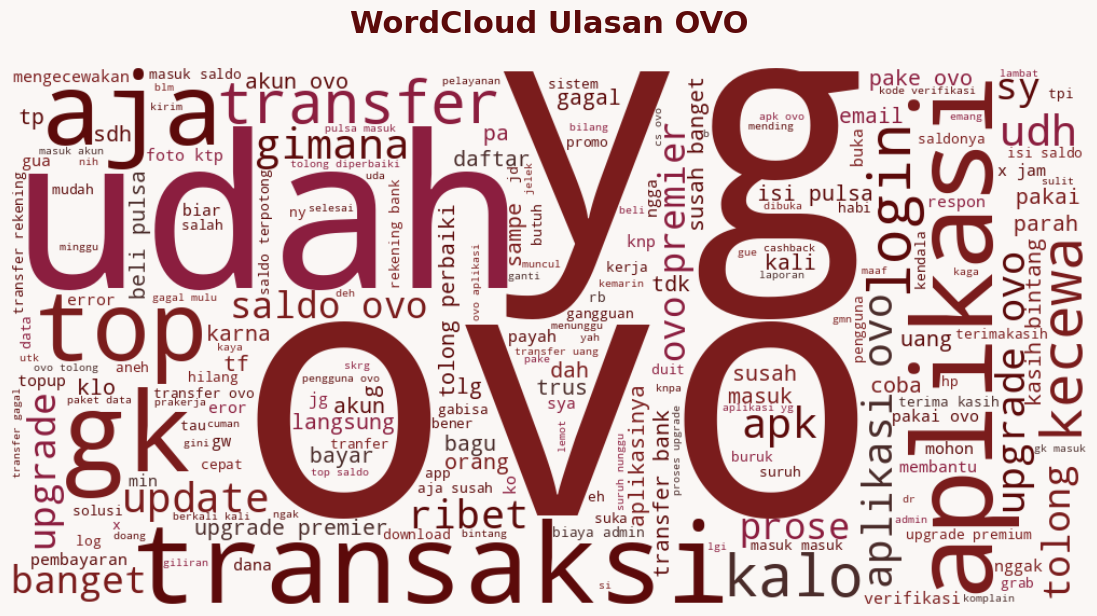

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

general_palette = ["#5C0A0A", "#7A1C1C", "#8B1E3F", "#4A2C2A"]

def general_color_func(*args, **kwargs):
    return random.choices(
        general_palette,
        weights=[0.4, 0.3, 0.2, 0.1]  # dominan burgundy
    )[0]

general_text = ' '.join(clean_df['text_akhir'])

wc_general = WordCloud(
    width=1000,
    height=500,
    background_color="#FAF7F5",
    color_func=general_color_func
).generate(general_text)

plt.figure(figsize=(14,7), facecolor="#FAF7F5")
plt.imshow(wc_general, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Ulasan OVO", fontsize=22, fontweight="bold", color="#5C0A0A", pad=25)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.9, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

# konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# menampilkan hasil ekstraksi fitur
features_df

# bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

Logistic Regression | accuracy_train: 0.9394309239288837
Logistic Regression | accuracy_test: 0.927572136403381


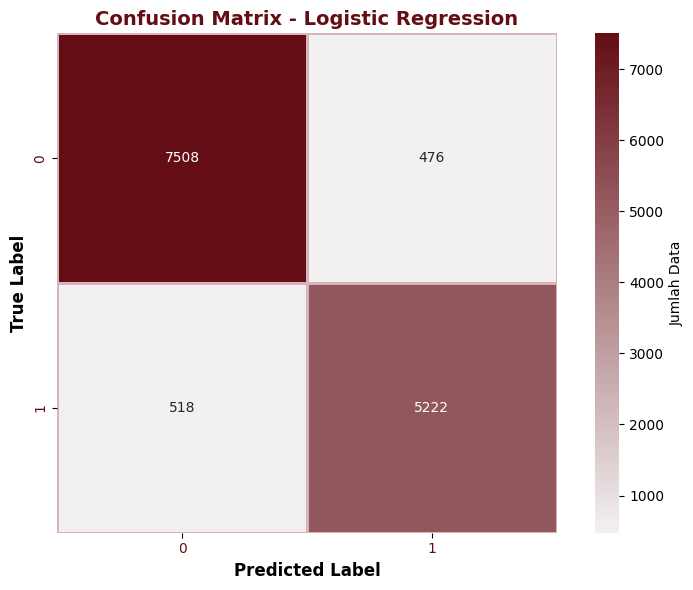


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

    negative       0.94      0.94      0.94      7984
    positive       0.92      0.91      0.91      5740

    accuracy                           0.93     13724
   macro avg       0.93      0.93      0.93     13724
weighted avg       0.93      0.93      0.93     13724



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# melatih model logistic regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# evaluasi akurasi model logistic regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# evaluasi akurasi model logistic regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# menampilkan akurasi
print('Logistic Regression | accuracy_train:', accuracy_train_lr)
print('Logistic Regression | accuracy_test:', accuracy_test_lr)

# Confusion matrix untuk Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_test_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap=sns.light_palette("#640D14", as_cmap=True),
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=1,
            linecolor="#D9B3BC",
            square=True)

plt.title('Confusion Matrix - Logistic Regression',
          fontsize=14,
          fontweight='bold',
          color="#640D14")
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(color="#640D14")
plt.yticks(color="#640D14")
plt.tight_layout()
plt.show()

# Tampilkan classification report
from sklearn.metrics import classification_report
print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_test_lr))



Naive Bayes | accuracy_train: 0.8138480034975226
Naive Bayes | accuracy_test: 0.8061789565724279


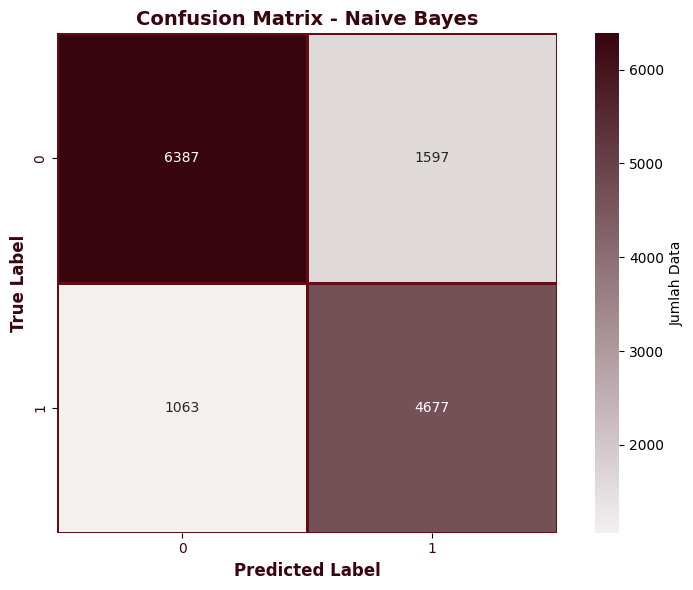

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix

# membuat objek model naive bayes
naive_bayes = BernoulliNB()

# melatih model naive bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)

# prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# evaluasi akurasi model logistic regression pada data pelatihan
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)

# evaluasi akurasi model logistic regression pada data uji
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# menampilkan akurasi
print('Naive Bayes | accuracy_train:', accuracy_train_nb)
print('Naive Bayes | accuracy_test:', accuracy_test_nb)

cm_nb = confusion_matrix(y_test, y_pred_test_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb,
            annot=True,
            fmt='d',
            cmap=sns.light_palette("#38040E", as_cmap=True),
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=2,
            linecolor="#640D14",
            square=True)

plt.title('Confusion Matrix - Naive Bayes',
          fontsize=14,
          fontweight='bold',
          color="#38040E")
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', color="#38040E")
plt.ylabel('True Label', fontsize=12, fontweight='bold', color="#38040E")
plt.xticks(color="#38040E")
plt.yticks(color="#38040E")
plt.tight_layout()
plt.show()

Random Forest | accuracy_train: 0.9990527542990382
Random Forest | accuracy_test: 0.861993587875255


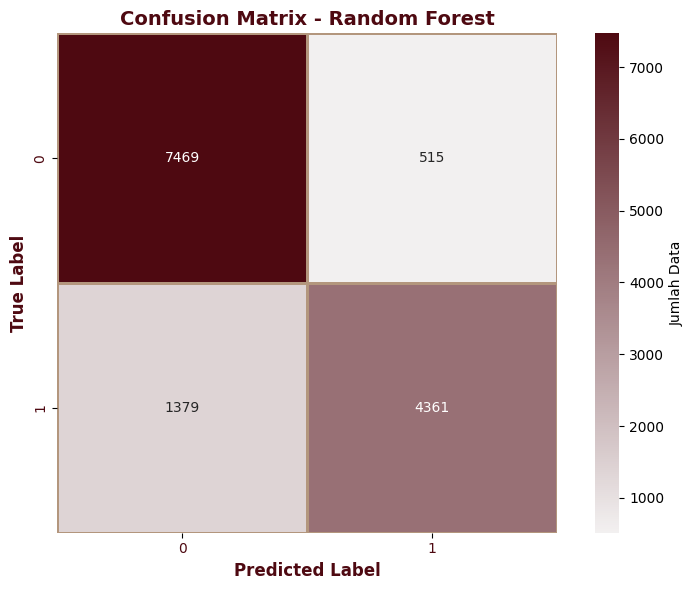

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# membuat objek model random forest
random_forest = RandomForestClassifier()

# melatih model forest forest pada data pelatihan
random_forest.fit(X_train.toarray(), y_train)

# prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# evaluasi akurasi model random forest pada data pelatihan
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)

# evaluasi akurasi model random forest pada data uji
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

# menampilkan akurasi
print('Random Forest | accuracy_train:', accuracy_train_rf)
print('Random Forest | accuracy_test:', accuracy_test_rf)

cm_rf = confusion_matrix(y_test, y_pred_test_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap=sns.light_palette("#4E0911", as_cmap=True),
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=2,
            linecolor="#B3967D",
            square=True)

plt.title('Confusion Matrix - Random Forest',
          fontsize=14,
          fontweight='bold',
          color="#4E0911")
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', color="#4E0911")
plt.ylabel('True Label', fontsize=12, fontweight='bold', color="#4E0911")
plt.xticks(color="#4E0911")
plt.yticks(color="#4E0911")
plt.tight_layout()
plt.show()

SVM | accuracy_train: 0.9539
SVM | accuracy_test: 0.9408

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95      7984
    positive       0.93      0.93      0.93      5740

    accuracy                           0.94     13724
   macro avg       0.94      0.94      0.94     13724
weighted avg       0.94      0.94      0.94     13724



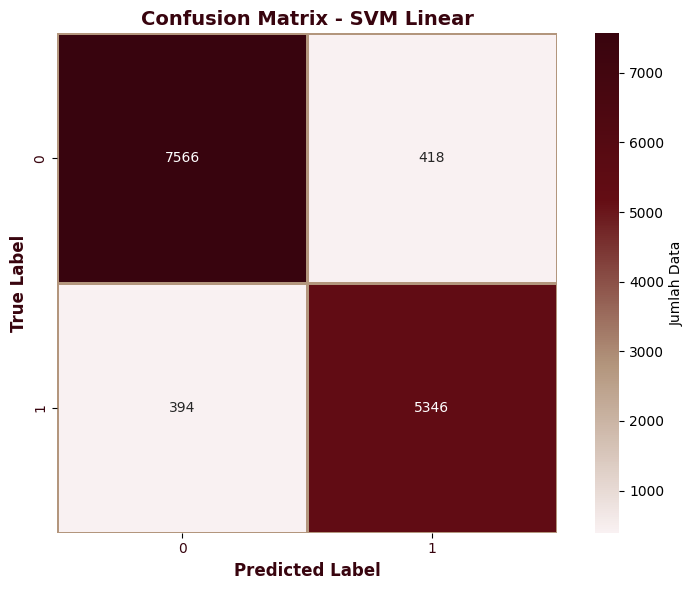

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from matplotlib.colors import LinearSegmentedColormap

svm_model = LinearSVC(
    C=1.0,
    max_iter=500,
    random_state=42,
    dual=False,
    verbose=0
)

svm_model.fit(X_train, y_train)

y_pred_train_svm = svm_model.predict(X_train)
y_pred_test_svm = svm_model.predict(X_test)

accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test)

print(f'SVM | accuracy_train: {accuracy_train_svm:.4f}')
print(f'SVM | accuracy_test: {accuracy_test_svm:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_test_svm))

colors_svm = ["#F9F1F2", "#B3967D", "#640D14", "#38040E"]
svm_cmap = LinearSegmentedColormap.from_list("deep_burgundy", colors_svm, N=256)

cm_svm = confusion_matrix(y_test, y_pred_test_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap=svm_cmap,
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=2,
            linecolor="#B3967D",
            square=True)

plt.title('Confusion Matrix - SVM Linear',
          fontsize=14,
          fontweight='bold',
          color="#38040E")
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', color="#38040E")
plt.ylabel('True Label', fontsize=12, fontweight='bold', color="#38040E")
plt.xticks(color="#38040E")
plt.yticks(color="#38040E")
plt.tight_layout()
plt.show()